# DS5104: Statistical Methods for Data Science — Final Assessment

**NAME:LOUISA NAATEKIE NARTEY** 

**ROLL NUMBER:2000250069** 

In [41]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

pd.set_option('display.width', 200)

In [42]:
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = (
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100",
    "#e87ba4", "#008300", "#4a3aa7", "#e34948",
)
SEQ_BLUE = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95"]  # light -> dark
INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRIDLINE, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK_SECONDARY,
    "text.color": INK_PRIMARY,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "axes.grid": True,
    "grid.color": GRIDLINE,
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
    "figure.dpi": 100,
})

def style_ax(ax, grid_axis="y"):
    ax.grid(axis=grid_axis, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    return ax

## Part A: FitPulse Health Dataset Analysis

In [43]:
fp = pd.read_csv("../data/fitpulse_health_dataset.csv")
fp["is_premium"] = (fp["subscription_tier"] == "Premium").astype(int)
fp.head()

,user_id,age,subscription_tier,ab_test_group,daily_steps_avg,sleep_quality_score,supplement_purchases,churned_within_6mo,is_premium
0,1001,58.8,Basic,Variant_B,2116.0,4.8,0,1,0
1,1002,48.6,Basic,Control,4981.0,9.8,0,1,0
2,1003,47.3,Basic,Control,2529.0,5.1,0,0,0
3,1004,47.3,Basic,Variant_B,3233.0,6.1,0,1,0
4,1005,80.8,Free,Variant_B,2784.0,4.9,0,1,0


### 1. Normality & Descriptive Metrics

(a)Null Hypohesis (H0): `daily_steps_avg` is drawn from a normally distributed population.

Alternative Hypothesis (H1): `daily_steps_avg` is not drawn from a normally distributed population.

In [44]:
w, p = stats.shapiro(fp["daily_steps_avg"])
print(f"W = {w:.4f}, p = {p:.6g}")
print(f"Mean = {fp['daily_steps_avg'].mean():.2f}, SD = {fp['daily_steps_avg'].std():.2f}")
med = fp["daily_steps_avg"].median()
q1, q3 = fp["daily_steps_avg"].quantile([0.25, 0.75])
print(f"Median = {med:.2f}, IQR = {q1:.2f} - {q3:.2f} ({q3-q1:.2f})")
print(f"Skew = {fp['daily_steps_avg'].skew():.3f}, Kurtosis = {fp['daily_steps_avg'].kurt():.3f}")

W = 0.9844, p = 7.22331e-09
Mean = 3267.01, SD = 1275.52
Median = 3184.00, IQR = 2374.75 - 4163.25 (1788.50)
Skew = 0.378, Kurtosis = -0.145


In [45]:
# Supporting check on age (flagged for a known data-entry issue -- see markdown below)
w2, p2 = stats.shapiro(fp["age"])
print(f"W = {w2:.4f}, p = {p2:.6g}")
print(f"Mean = {fp['age'].mean():.2f}, SD = {fp['age'].std():.2f}")
med_a = fp["age"].median()
q1a, q3a = fp["age"].quantile([0.25, 0.75])
print(f"Median = {med_a:.2f}, IQR = {q1a:.2f} - {q3a:.2f} ({q3a-q1a:.2f})")
print(f"min={fp['age'].min()}, max={fp['age'].max()}  <-- implausible max, data-quality issue")

W = 0.9527, p = 2.06103e-17
Mean = 53.77, SD = 15.67
Median = 51.40, IQR = 42.40 - 62.17 (19.77)
min=22.1, max=150.4  <-- implausible max, data-quality issue


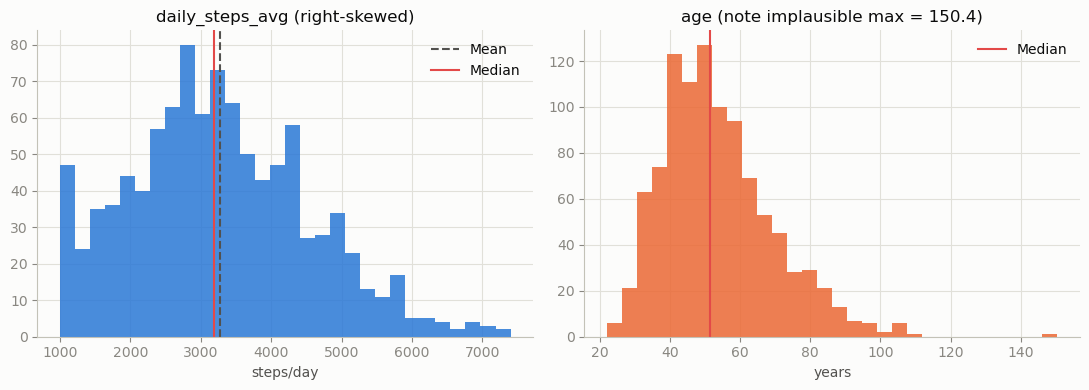

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.hist(fp["daily_steps_avg"], bins=30, color=BLUE, alpha=0.85, zorder=2)
ax.axvline(fp["daily_steps_avg"].mean(), color=INK_SECONDARY, linestyle="--", linewidth=1.5, label="Mean")
ax.axvline(fp["daily_steps_avg"].median(), color=RED, linewidth=1.5, label="Median")
style_ax(ax)
ax.set_title("daily_steps_avg (right-skewed)")
ax.set_xlabel("steps/day")
ax.legend(frameon=False)

ax = axes[1]
ax.hist(fp["age"], bins=30, color=ORANGE, alpha=0.85, zorder=2)
ax.axvline(fp["age"].median(), color=RED, linewidth=1.5, label="Median")
style_ax(ax)
ax.set_title("age (note implausible max = 150.4)")
ax.set_xlabel("years")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

**(b) Result & decision:** W = 0.9844, p = 7.22 × 10⁻⁹ → **reject H0**.
`daily_steps_avg` significantly deviates from normality (skew = 0.378,
kurtosis = −0.145 — mild right skew; with N = 1000 the test is highly
sensitive to small deviations, but the result stands at the stated α).

 Shapiro-Wilk tests
$$
W=\frac{\left(\sum_{i=1}^{n} a_i\, x_{(i)}\right)^{2}}{\sum_{i=1}^{n}\left(x_i-\bar x\right)^{2}},
$$


**Metric choice & justification:** Report **Median (IQR)**: Median = 3184.00,
IQR = 2374.75 – 4163.25 (width 1788.50). Since normality is formally
rejected, the median/IQR are robust to residual skew/outliers and don't
assume a symmetric distribution the way Mean (SD) does; Mean (SD) = 3267.01
(1275.52) is reported for reference but is the secondary metric here.

### 2. Count Data Fundamentals

**(a) Why OLS fails for `supplement_purchases`:**

1. **Range mismatch:** OLS assumes an unbounded, continuous response with
   normally distributed errors. Count data is discrete and bounded at 0, so
   OLS can (and will) predict negative or non-integer purchase counts, which
   are meaningless for this outcome.
2. **Heteroscedasticity:** Count data variance typically scales with the
   mean (as in a Poisson process) rather than staying constant, violating
   OLS's homoscedasticity assumption.

In [47]:
m = fp["supplement_purchases"].mean()
v = fp["supplement_purchases"].var()
print(f"Mean = {m:.4f}, Variance = {v:.4f}, Variance/Mean ratio = {v/m:.3f}")

Mean = 0.5340, Variance = 0.6435, Variance/Mean ratio = 1.205


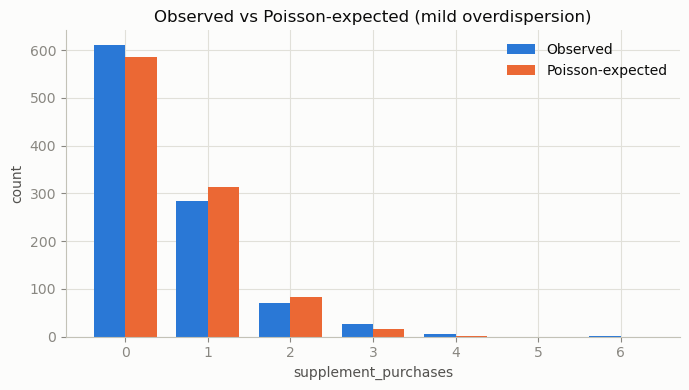

In [48]:
obs_counts = fp["supplement_purchases"].value_counts().sort_index()
k = obs_counts.index.values
expected_counts = stats.poisson.pmf(k, mu=m) * len(fp)

fig, ax = plt.subplots(figsize=(7, 4))
width = 0.38
ax.bar(k - width/2, obs_counts.values, width=width, color=BLUE, label="Observed", zorder=2)
ax.bar(k + width/2, expected_counts, width=width, color=ORANGE, label="Poisson-expected", zorder=2)
style_ax(ax)
ax.set_xlabel("supplement_purchases")
ax.set_ylabel("count")
ax.set_title("Observed vs Poisson-expected (mild overdispersion)")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

**(b) Suitable distribution:** The **Poisson distribution** is the natural
baseline: independent events, a constant average rate, and
**equidispersion** (variance = mean). Empirically mean = 0.534, variance =
0.644 (ratio ≈ 1.21) → mild **overdispersion**. When variance exceeds the
mean, plain Poisson understates true standard errors, inflating
z-statistics and producing spuriously significant predictors. The standard
remedy is **Negative Binomial** regression, which adds a dispersion
parameter to absorb the excess variance.

### 3. A/B Experimentation

**(a) Hypotheses**

H0: μ_Control = μ_Variant B (no difference in mean daily steps).

H1: μ_Control ≠ μ_Variant B (difference in mean daily steps).

In [49]:
ctrl = fp.loc[fp.ab_test_group == "Control", "daily_steps_avg"]
var_b = fp.loc[fp.ab_test_group == "Variant_B", "daily_steps_avg"]
lev_stat, lev_p = stats.levene(ctrl, var_b)
print(f"Levene's test for equal variances: stat={lev_stat:.4f}, p={lev_p:.4f}")
equal_var = lev_p >= 0.05
t_stat, t_p = stats.ttest_ind(ctrl, var_b, equal_var=equal_var)
df_t = len(ctrl) + len(var_b) - 2 if equal_var else None
print(f"n_control={len(ctrl)}, mean={ctrl.mean():.2f}, sd={ctrl.std():.2f}")
print(f"n_variantB={len(var_b)}, mean={var_b.mean():.2f}, sd={var_b.std():.2f}")
print(f"equal_var assumption used: {equal_var}")
print(f"t = {t_stat:.4f}, df = {df_t}, p = {t_p:.6g}")
pooled_sd = np.sqrt(((len(ctrl)-1)*ctrl.var() + (len(var_b)-1)*var_b.var()) / (len(ctrl)+len(var_b)-2))
cohens_d = (var_b.mean() - ctrl.mean()) / pooled_sd
print(f"Cohen's d = {cohens_d:.4f}")

Levene's test for equal variances: stat=0.0019, p=0.9649
n_control=506, mean=3230.00, sd=1263.84
n_variantB=494, mean=3304.93, sd=1287.56
equal_var assumption used: True
t = -0.9286, df = 998, p = 0.353313
Cohen's d = 0.0587


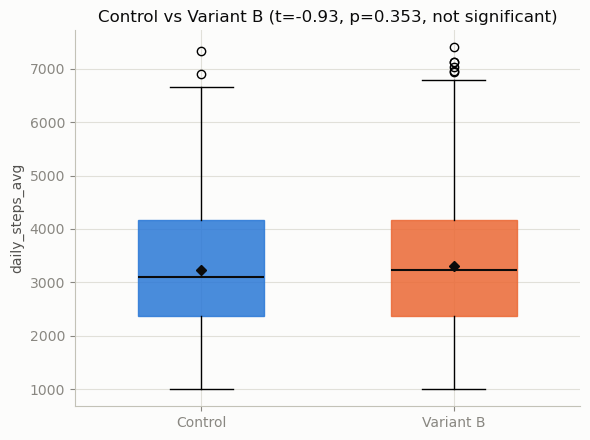

In [50]:
fig, ax = plt.subplots(figsize=(6, 4.5))
bp = ax.boxplot([ctrl.values, var_b.values], patch_artist=True, widths=0.5, showmeans=True,
                 medianprops=dict(color=INK_PRIMARY, linewidth=1.5),
                 meanprops=dict(marker="D", markerfacecolor=INK_PRIMARY, markeredgecolor=INK_PRIMARY, markersize=5))
for patch, color in zip(bp["boxes"], [BLUE, ORANGE]):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
    patch.set_edgecolor(color)
ax.set_xticklabels(["Control", "Variant B"])
style_ax(ax)
ax.set_ylabel("daily_steps_avg")
ax.set_title(f"Control vs Variant B (t={t_stat:.2f}, p={t_p:.3f}, not significant)")
plt.tight_layout()
plt.show()

**Decision:** Levene's test confirms equal variances (stat = 0.002,
p = 0.965), so the pooled-variance t-test applies. **t = −0.9286, df = 998,
p = 0.3533.** Cohen's d = 0.059 (negligible effect). p > 0.05 →
**fail to reject H0**. No statistically significant difference in daily
steps between groups.

**Deployment recommendation:** Do not ship Variant B on the strength of this
result — the observed lift is small, statistically indistinguishable from
noise, and the effect size is trivial. With N ≈ 1000 already, a meaningful
real-world effect likely would have been detected; recommend either holding
the current experience or investigating a different lever.

**(c) Type I / Type II in context:**
- **Type I (α):** Concluding Variant B improves steps when it doesn't →
  shipping a change with engineering/design cost and no real user benefit.
- **Type II (β):** Concluding no difference when Variant B truly helps →
  forgoing a real engagement improvement, ceding an opportunity to a
  competitor. Given the negligible effect size actually observed, β risk
  here is low.

### 4. Categorical Association

H0: `subscription_tier` and `churned_within_6mo` are independent.

H1: `subscription_tier` and `churned_within_6mo` are associated.

In [51]:
tbl = pd.crosstab(fp.subscription_tier, fp.churned_within_6mo)
tbl = tbl[[0, 1]]
print("Observed:\n", tbl)
chi2, p_chi, dof, expected = stats.chi2_contingency(tbl)
exp_df = pd.DataFrame(expected, index=tbl.index, columns=tbl.columns)
print("\nExpected:\n", exp_df.round(2))
print(f"\nchi2 = {chi2:.4f}, df = {dof}, p = {p_chi:.6g}")
churn_rate = fp.groupby("subscription_tier")["churned_within_6mo"].mean().sort_values()
print("\nChurn rate by tier:\n", churn_rate.round(3))
std_resid = (tbl - exp_df) / np.sqrt(exp_df)
print("\nStandardized residuals:\n", std_resid.round(2))

Observed:
 churned_within_6mo   0    1
subscription_tier          
Basic               23  281
Free                58  453
Premium             35  150

Expected:
 churned_within_6mo      0       1
subscription_tier                
Basic               35.26  268.74
Free                59.28  451.72
Premium             21.46  163.54

chi2 = 14.5198, df = 2, p = 0.000703161

Churn rate by tier:
 subscription_tier
Premium    0.811
Free       0.886
Basic      0.924
Name: churned_within_6mo, dtype: float64

Standardized residuals:
 churned_within_6mo     0     1
subscription_tier             
Basic              -2.07  0.75
Free               -0.17  0.06
Premium             2.92 -1.06


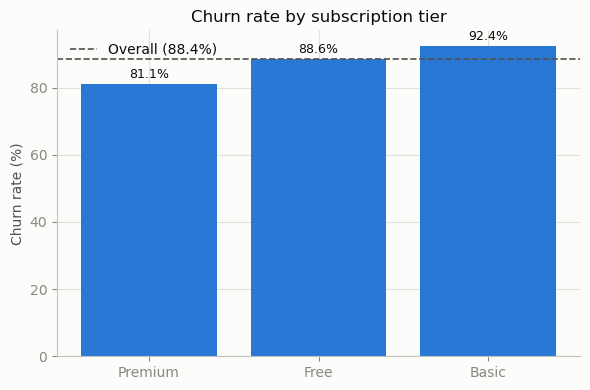

In [52]:
order = churn_rate.index.tolist()
rates = churn_rate.loc[order].values * 100
overall = fp["churned_within_6mo"].mean() * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(order, rates, color=BLUE, zorder=2)
ax.axhline(overall, color=INK_SECONDARY, linestyle="--", linewidth=1.2, label=f"Overall ({overall:.1f}%)")
for bar, val in zip(bars, rates):
    ax.annotate(f"{val:.1f}%", (bar.get_x() + bar.get_width() / 2, val),
                textcoords="offset points", xytext=(0, 4), ha="center", fontsize=9, color=INK_PRIMARY)
style_ax(ax)
ax.set_ylabel("Churn rate (%)")
ax.set_title("Churn rate by subscription tier")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

**χ² = 14.5198, df = 2, p = 0.000703.** p < 0.05 → **reject H0**. Tier and
churn are significantly associated.

**Retention insight:** Churn rate is highest for **Basic** (92.4%), then
**Free** (88.6%), lowest for **Premium** (81.1%). Standardized residuals
show Basic is retaining *fewer* users than expected (residual −2.07 in the
not-churned cell) while Premium retains *more* than expected (residual
+2.92). Actionable takeaway: Premium subscribers churn least — retention
efforts and upsell-to-Premium campaigns are the highest-leverage lever,
while Basic tier needs a targeted retention intervention.

### 5. Multiple Linear Regression

Model: `daily_steps_avg ~ age + sleep_quality_score`

In [53]:
m5 = smf.ols("daily_steps_avg ~ age + sleep_quality_score", data=fp).fit()
print(m5.summary())
X5 = sm.add_constant(fp[["age", "sleep_quality_score"]])
vif5 = pd.DataFrame({
    "variable": X5.columns,
    "VIF": [variance_inflation_factor(X5.values, i) for i in range(X5.shape[1])]
})
print("\nVIF:\n", vif5)

                            OLS Regression Results                            
Dep. Variable:        daily_steps_avg   R-squared:                       0.152
Model:                            OLS   Adj. R-squared:                  0.150
Method:                 Least Squares   F-statistic:                     89.15
Date:                Thu, 30 Jul 2026   Prob (F-statistic):           2.41e-36
Time:                        21:35:06   Log-Likelihood:                -8487.3
No. Observations:                1000   AIC:                         1.698e+04
Df Residuals:                     997   BIC:                         1.700e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            3170.8435    

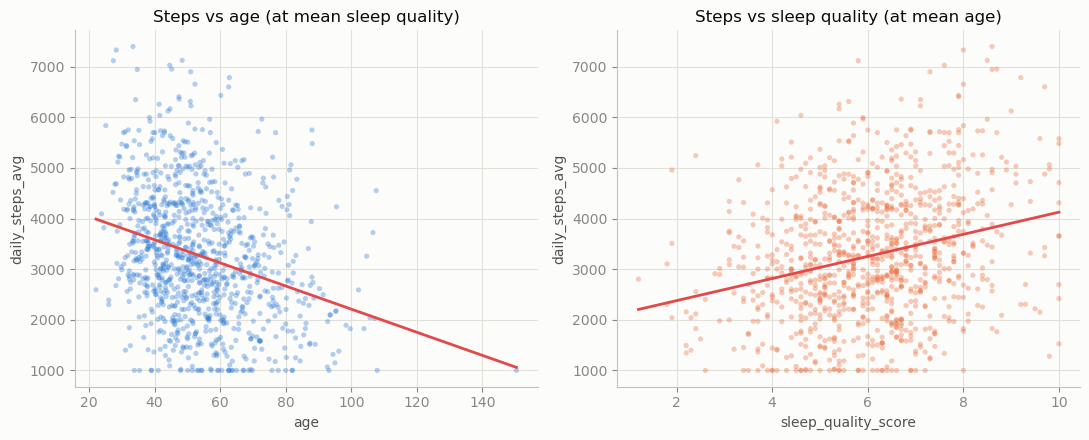

In [54]:
b0, b1, b2 = m5.params["Intercept"], m5.params["age"], m5.params["sleep_quality_score"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ax = axes[0]
ax.scatter(fp["age"], fp["daily_steps_avg"], s=14, color=BLUE, alpha=0.35, edgecolors="none", zorder=2)
xs = np.linspace(fp["age"].min(), fp["age"].max(), 100)
ax.plot(xs, b0 + b1 * xs + b2 * fp["sleep_quality_score"].mean(), color=RED, linewidth=2, zorder=3)
style_ax(ax)
ax.set_xlabel("age")
ax.set_ylabel("daily_steps_avg")
ax.set_title("Steps vs age (at mean sleep quality)")

ax = axes[1]
ax.scatter(fp["sleep_quality_score"], fp["daily_steps_avg"], s=14, color=ORANGE, alpha=0.35, edgecolors="none", zorder=2)
xs2 = np.linspace(fp["sleep_quality_score"].min(), fp["sleep_quality_score"].max(), 100)
ax.plot(xs2, b0 + b1 * fp["age"].mean() + b2 * xs2, color=RED, linewidth=2, zorder=3)
style_ax(ax)
ax.set_xlabel("sleep_quality_score")
ax.set_ylabel("daily_steps_avg")
ax.set_title("Steps vs sleep quality (at mean age)")

plt.tight_layout()
plt.show()

R² = 0.152, Adj. R² = 0.150, F(2,997) = 89.15, p < 0.001.

**(a) Interpretation:**
- **β0 (3170.84):** Predicted daily steps when age = 0 and sleep quality = 0
  — not practically meaningful (extrapolation outside observed data), it
  only anchors the model.
- **β1 (−22.85):** Holding sleep quality constant, each additional year of
  age is associated with **22.85 fewer** average daily steps.
- **β2 (218.42):** Holding age constant, each 1-point increase in sleep
  quality score is associated with **218.42 more** average daily steps — the
  dominant driver of activity in this model.

**(b) Predictor significance:** Both partial t-tests are significant at
α = 0.05 (age: t = −9.62, p < 0.001; sleep quality: t = 8.94, p < 0.001) —
both variables contribute independently to explaining steps.

**(c) Multicollinearity & VIF:** Multicollinearity is when two or more
predictors are strongly linearly correlated, making it hard to isolate each
predictor's individual effect. VIF quantifies this by regressing each
predictor on all others and computing 1/(1 − R²ⱼ); VIF > 5 (or 10,
depending on convention) signals a problem. Here, VIF(age) = 1.001 and
VIF(sleep_quality_score) = 1.001 — essentially no collinearity. High VIF
(not the case here) inflates coefficient standard errors, widening
confidence intervals and making individual t-tests unreliable even when the
overall model fits well; since VIF is ~1 for both predictors, the standard
errors above can be trusted.

### 6. Logistic Regression & Classification

Model: `logit(churn) = β0 + β1(age) + β2(is_Premium)`

In [55]:
X6 = sm.add_constant(fp[["age", "is_premium"]])
y6 = fp["churned_within_6mo"]
m6 = sm.Logit(y6, X6).fit(disp=0)
print(m6.summary())
orA = np.exp(m6.params)
ci = m6.conf_int()
ci_exp = np.exp(ci)
print("\nOdds Ratios:\n", pd.DataFrame({"OR": orA, "CI_low": ci_exp[0], "CI_high": ci_exp[1]}))

                           Logit Regression Results                           
Dep. Variable:     churned_within_6mo   No. Observations:                 1000
Model:                          Logit   Df Residuals:                      997
Method:                           MLE   Df Model:                            2
Date:                Thu, 30 Jul 2026   Pseudo R-squ.:                 0.02665
Time:                        21:35:06   Log-Likelihood:                -349.32
converged:                       True   LL-Null:                       -358.88
Covariance Type:            nonrobust   LLR p-value:                 7.030e-05
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.1580      0.380      3.051      0.002       0.414       1.902
age            0.0200      0.007      2.803      0.005       0.006       0.034
is_premium    -0.7235      0.223     -3.251      0.0

In [56]:
pred_prob = m6.predict(X6)
pred_class = (pred_prob >= 0.5).astype(int)
print(f"Accuracy  = {accuracy_score(y6, pred_class):.4f}")
print(f"Precision = {precision_score(y6, pred_class, zero_division=0):.4f}")
print(f"Recall    = {recall_score(y6, pred_class):.4f}")
print(f"ROC-AUC   = {roc_auc_score(y6, pred_prob):.4f}")
print(f"Predicted class distribution: {pd.Series(pred_class).value_counts().to_dict()}  (base rate churned={y6.mean():.3f})")

Accuracy  = 0.8840
Precision = 0.8840
Recall    = 1.0000
ROC-AUC   = 0.6137
Predicted class distribution: {1: 1000}  (base rate churned=0.884)


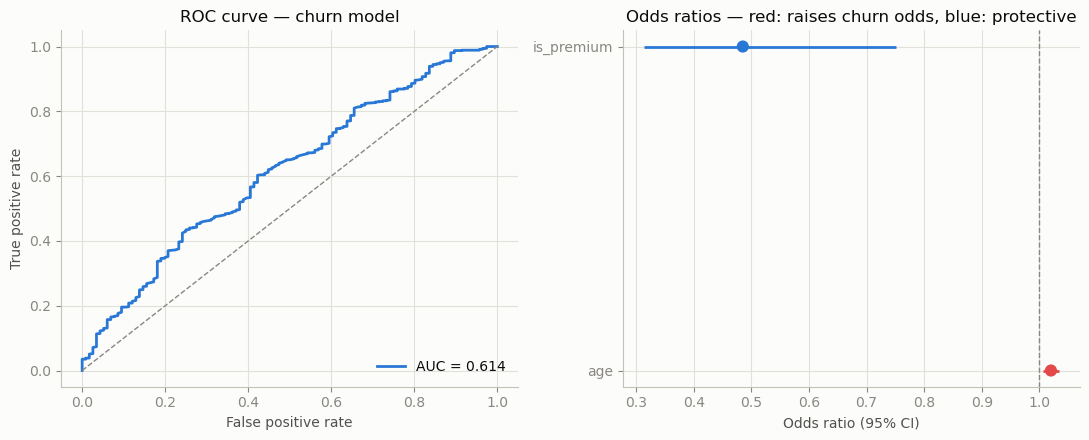

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ax = axes[0]
fpr, tpr, _ = roc_curve(y6, pred_prob)
ax.plot(fpr, tpr, color=BLUE, linewidth=2, label=f"AUC = {roc_auc_score(y6, pred_prob):.3f}")
ax.plot([0, 1], [0, 1], color=INK_MUTED, linestyle="--", linewidth=1)
style_ax(ax)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curve — churn model")
ax.legend(frameon=False, loc="lower right")

ax = axes[1]
terms = ["age", "is_premium"]
or_vals = orA.loc[terms]
lo, hi = ci_exp[0].loc[terms], ci_exp[1].loc[terms]
colors = [RED if o > 1 else BLUE for o in or_vals]
y_pos = np.arange(len(terms))
ax.hlines(y_pos, lo, hi, color=colors, linewidth=2, zorder=2)
ax.scatter(or_vals, y_pos, color=colors, s=60, zorder=3)
ax.axvline(1, color=INK_MUTED, linestyle="--", linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(terms)
style_ax(ax, grid_axis="x")
ax.set_xlabel("Odds ratio (95% CI)")
ax.set_title("Odds ratios — red: raises churn odds, blue: protective")

plt.tight_layout()
plt.show()

**(a) Why logit is preferred over linear models:** A linear probability model can predict
outside [0, 1], which is nonsensical for a probability, and violates the
constant-variance/normal-error assumptions OLS needs. The logit link maps a
linear combination of predictors onto (0, 1) via the log-odds transform,
which is the natural link for a Bernoulli/binary outcome and guarantees
valid probability predictions.


**(b) Odds ratios:**
- **Age (OR = 1.0202):** Each additional year of age is associated with a
  **2.02% increase** in the odds of churning, holding tier constant.
- **Premium tier (OR = 0.4850):** Being on the Premium tier is associated
  with **51.5% lower odds** of churning relative to non-Premium, holding age
  constant. **Yes — Premium tier reduces churn odds** (OR < 1, and the 95%
  CI [0.314, 0.750] excludes 1, confirming significance).

**(c) Model performance:** At the default 0.5 threshold: **Accuracy = 0.884,
Precision = 0.884, Recall = 1.000, ROC-AUC = 0.614**.

Interpretation caveat (important given the class imbalance): the base churn
rate is 88.4%, and at threshold 0.5 the model predicts **every** observation
as "churned" — so Accuracy/Precision/Recall trivially match the base rate
and a perfect recall, not genuine discrimination. **ROC-AUC = 0.614** (only
modestly above the 0.5 chance line) is the more honest measure here and
indicates weak-to-modest discriminatory power; a lower classification
threshold or a different metric (e.g., balanced accuracy, PR-AUC) would be
needed to meaningfully separate churners from retainers in practice.

ROC-AUC has a threshold-free probabilistic definition that's why it isn't
fooled by the "predict everything churned" degeneracy above:
$$
\text{AUC}=P\big(\hat p_{\text{churn}} > \hat p_{\text{retain}}\big)
$$
for a randomly drawn churned/retained pair — equivalently, the ROC curve
plots $\text{TPR}(c)$ vs $\text{FPR}(c)$ swept over every threshold $c$, and
AUC is the area under that curve. $\text{AUC}=0.614$ means the model ranks a
random churner above a random non-churner only 61.4% of the time — barely
better than the $\text{AUC}=0.5$ coin flip, confirming the weak
discrimination the accuracy/recall numbers alone conceal.

## Part B: Seaborn `tips` Dataset Analysis (N = 244)

In [58]:
tips = sns.load_dataset("tips")
tips["high_tip"] = (tips["tip"] >= 3.00).astype(int)
tips["is_smoker"] = (tips["smoker"] == "Yes").astype(int)
print(f"N = {len(tips)}")
tips.head()

N = 244


,total_bill,tip,sex,smoker,day,time,size,high_tip,is_smoker
0,16.99,1.01,Female,No,Sun,Dinner,2,0,0
1,10.34,1.66,Male,No,Sun,Dinner,3,0,0
2,21.01,3.50,Male,No,Sun,Dinner,3,1,0
3,23.68,3.31,Male,No,Sun,Dinner,2,1,0
4,24.59,3.61,Female,No,Sun,Dinner,4,1,0


### 1(a). Distributional Assessment

H0: `total_bill` is normally distributed 

H1: it is not normally distributed

In [59]:
wb, pb = stats.shapiro(tips["total_bill"])
print(f"W = {wb:.4f}, p = {pb:.6g}")
print(f"Mean = {tips['total_bill'].mean():.2f}, SD = {tips['total_bill'].std():.2f}")
medb = tips["total_bill"].median()
q1b, q3b = tips["total_bill"].quantile([0.25, 0.75])
print(f"Median = {medb:.2f}, IQR = {q1b:.2f} - {q3b:.2f} ({q3b-q1b:.2f})")
print(f"Skew = {tips['total_bill'].skew():.3f}")

W = 0.9197, p = 3.32454e-10
Mean = 19.79, SD = 8.90
Median = 17.80, IQR = 13.35 - 24.13 (10.78)
Skew = 1.133


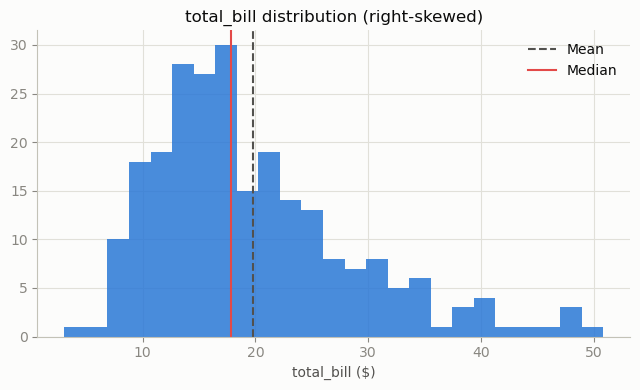

In [60]:
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.hist(tips["total_bill"], bins=25, color=BLUE, alpha=0.85, zorder=2)
ax.axvline(tips["total_bill"].mean(), color=INK_SECONDARY, linestyle="--", linewidth=1.5, label="Mean")
ax.axvline(tips["total_bill"].median(), color=RED, linewidth=1.5, label="Median")
style_ax(ax)
ax.set_xlabel("total_bill ($)")
ax.set_title("total_bill distribution (right-skewed)")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

**(b)** **W = 0.9197, p = 3.32 × 10⁻¹⁰** → **reject H0**. Distribution is
right-skewed (skew = 1.133).
- Mean (SD) = 19.79 (8.90)
- **Median (IQR) = 17.80 (13.35 – 24.13)** ← recommended metric, given the
  rejected normality and visible right skew (a few large bills pull the
  mean upward relative to the typical bill).

### 2. Party Size Modeling

**(a)** OLS regression is unsuitable for discrete party counts like size because `size` is a small discrete count (1–6) with a
natural floor at 1 and no meaningful fractional values. OLS can predict
non-integer or out-of-range party sizes and assumes constant error
variance, which discrete count data with a mean-linked variance typically
violates.

In [61]:
ms = tips["size"].mean()
vs = tips["size"].var()
print(f"Mean = {ms:.4f}, Variance = {vs:.4f}, Variance/Mean ratio = {vs/ms:.3f}")

Mean = 2.5697, Variance = 0.9046, Variance/Mean ratio = 0.352


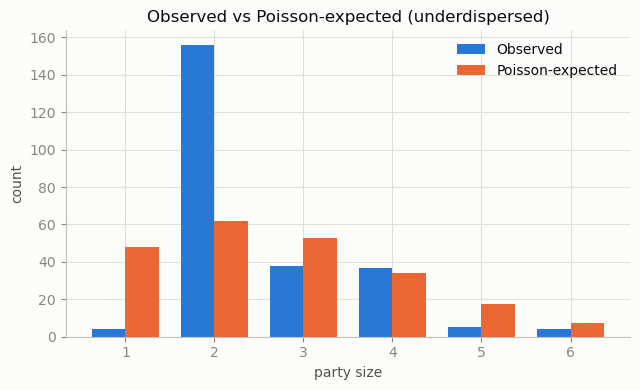

In [62]:
obs_size = tips["size"].value_counts().sort_index()
ks = obs_size.index.values
expected_size = stats.poisson.pmf(ks, mu=ms) * len(tips)

fig, ax = plt.subplots(figsize=(6.5, 4))
width = 0.38
ax.bar(ks - width/2, obs_size.values, width=width, color=BLUE, label="Observed", zorder=2)
ax.bar(ks + width/2, expected_size, width=width, color=ORANGE, label="Poisson-expected", zorder=2)
style_ax(ax)
ax.set_xlabel("party size")
ax.set_ylabel("count")
ax.set_title("Observed vs Poisson-expected (underdispersed)")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

**(b)** Poisson assumes **equidispersion** (Var = Mean). Here,
mean(`size`) = 2.570, variance = 0.905 (ratio ≈ 0.35) — this dataset is
actually **underdispersed** relative to Poisson, not overdispersed. The alternative models when variance exceeds the mean (variance > mean) is Negative Binomial regression; for the underdispersion observed here, the analogous
fix is a model that allows dispersion < 1 Examples, quasi-Poisson with an
estimated dispersion parameter, or a Conway-Maxwell-Poisson model.

### 3(a). Gender Spend Comparison 

H0: μ_Male = μ_Female. 

H1: μ_Male ≠ μ_Female.

In [63]:
male = tips.loc[tips.sex == "Male", "total_bill"]
female = tips.loc[tips.sex == "Female", "total_bill"]
lev_stat_b, lev_p_b = stats.levene(male, female)
print(f"Levene's test: stat={lev_stat_b:.4f}, p={lev_p_b:.4f}")
equal_var_b = lev_p_b >= 0.05
t_stat_b, t_p_b = stats.ttest_ind(male, female, equal_var=equal_var_b)
df_tb = len(male) + len(female) - 2 if equal_var_b else None
print(f"n_male={len(male)}, mean={male.mean():.2f}, sd={male.std():.2f}")
print(f"n_female={len(female)}, mean={female.mean():.2f}, sd={female.std():.2f}")
print(f"equal_var assumption used: {equal_var_b}")
print(f"t = {t_stat_b:.4f}, df = {df_tb}, p = {t_p_b:.6g}")
pooled_sd_b = np.sqrt(((len(male)-1)*male.var() + (len(female)-1)*female.var()) / (len(male)+len(female)-2))
cohens_d_b = (male.mean() - female.mean()) / pooled_sd_b
print(f"Pooled SD = {pooled_sd_b:.4f}, Cohen's d = {cohens_d_b:.4f}")

Levene's test: stat=1.6317, p=0.2027
n_male=157, mean=20.74, sd=9.25
n_female=87, mean=18.06, sd=8.01
equal_var assumption used: True
t = 2.2778, df = 242, p = 0.0236117
Pooled SD = 8.8267, Cohen's d = 0.3044


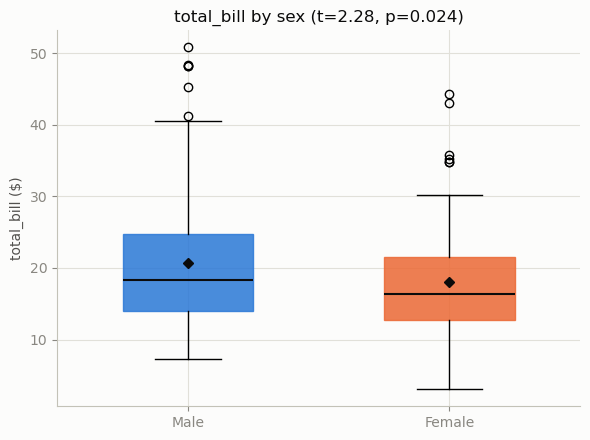

In [64]:
fig, ax = plt.subplots(figsize=(6, 4.5))
bp = ax.boxplot([male.values, female.values], patch_artist=True, widths=0.5, showmeans=True,
                 medianprops=dict(color=INK_PRIMARY, linewidth=1.5),
                 meanprops=dict(marker="D", markerfacecolor=INK_PRIMARY, markeredgecolor=INK_PRIMARY, markersize=5))
for patch, color in zip(bp["boxes"], [BLUE, ORANGE]):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
    patch.set_edgecolor(color)
ax.set_xticklabels(["Male", "Female"])
style_ax(ax)
ax.set_ylabel("total_bill ($)")
ax.set_title(f"total_bill by sex (t={t_stat_b:.2f}, p={t_p_b:.3f})")
plt.tight_layout()
plt.show()

Levene's test: p = 0.203 → equal variances assumed. **t = 2.2778, df = 242,
p = 0.0236.** p < 0.05 → **reject H0**. Male bill payers spend significantly
more on average than female bill payers.

**(b) Type I:** Concluding a real gender spend gap exists when it doesn't →
misallocating marketing/staffing based on a false pattern. 

**Type II:**
Missing a genuine spend difference → forgoing a legitimate
segmentation/upsell opportunity tailored to actual spending behavior.

### 4. Analysis of Variance & Independence

**(a) One-way ANOVA: `total_bill ~ day`**

H0: mean total bill is equal across Thur/Fri/Sat/Sun.

H1: at least one day differs.

In [65]:
groups = [g["total_bill"].values for _, g in tips.groupby("day", observed=True)]
day_names = [n for n, _ in tips.groupby("day", observed=True)]
f_stat, f_p = stats.f_oneway(*groups)
m4 = smf.ols("total_bill ~ C(day)", data=tips).fit()
anova_tbl = sm.stats.anova_lm(m4, typ=2)
print(anova_tbl)
print(f"\nF = {f_stat:.4f}, p = {f_p:.6g}")
print("\nGroup means:\n", tips.groupby("day", observed=True)["total_bill"].agg(["mean", "std", "count"]))

                sum_sq     df         F    PR(>F)
C(day)      643.941362    3.0  2.767479  0.042454
Residual  18614.522721  240.0       NaN       NaN

F = 2.7675, p = 0.0424538

Group means:
            mean       std  count
day                             
Thur  17.682742  7.886170     62
Fri   17.151579  8.302660     19
Sat   20.441379  9.480419     87
Sun   21.410000  8.832122     76


In [66]:
print("Tukey HSD post-hoc:")
tukey = pairwise_tukeyhsd(tips["total_bill"], tips["day"])
print(tukey)

Tukey HSD post-hoc:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   Fri    Sat   3.2898 0.4541 -2.4799  9.0595  False
   Fri    Sun   4.2584 0.2371 -1.5856 10.1025  False
   Fri   Thur   0.5312 0.9957 -5.4434  6.5057  False
   Sat    Sun   0.9686 0.8968 -2.6088   4.546  False
   Sat   Thur  -2.7586 0.2374 -6.5455  1.0282  False
   Sun   Thur  -3.7273 0.0668 -7.6264  0.1719  False
----------------------------------------------------


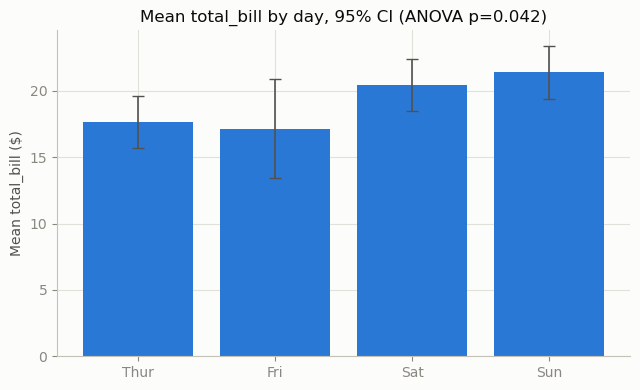

In [67]:
day_order = ["Thur", "Fri", "Sat", "Sun"]
day_means = tips.groupby("day", observed=True)["total_bill"].mean().reindex(day_order)
day_sems = tips.groupby("day", observed=True)["total_bill"].sem().reindex(day_order)

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.bar(day_order, day_means.values, yerr=day_sems.values * 1.96, capsize=4, color=BLUE, zorder=2,
       error_kw=dict(ecolor=INK_SECONDARY, linewidth=1.2))
style_ax(ax)
ax.set_ylabel("Mean total_bill ($)")
ax.set_title(f"Mean total_bill by day, 95% CI (ANOVA p={f_p:.3f})")
plt.tight_layout()
plt.show()

**Decision:** p = 0.0425 < 0.05 → **reject H0** (borderline). Mean total
bill differs significantly across days.

**Group means:** Thur 17.68, Fri 17.15, Sat 20.44, Sun 21.41 — bills trend
higher on weekends.

**(b) Chi-square: `sex` × `smoker`**

H0: sex and smoker status are independent. 

H1: sex and smoker are associated.

In [68]:
tbl_b = pd.crosstab(tips.sex, tips.smoker)
print("Observed:\n", tbl_b)
chi2_b, p_chi_b, dof_b, expected_b = stats.chi2_contingency(tbl_b)
print("\nExpected:\n", pd.DataFrame(expected_b, index=tbl_b.index, columns=tbl_b.columns).round(2))
print(f"\nchi2 = {chi2_b:.4f}, df = {dof_b}, p = {p_chi_b:.6g}")

Observed:
 smoker  Yes  No
sex            
Male     60  97
Female   33  54

Expected:
 smoker    Yes     No
sex                 
Male    59.84  97.16
Female  33.16  53.84

chi2 = 0.0000, df = 1, p = 1


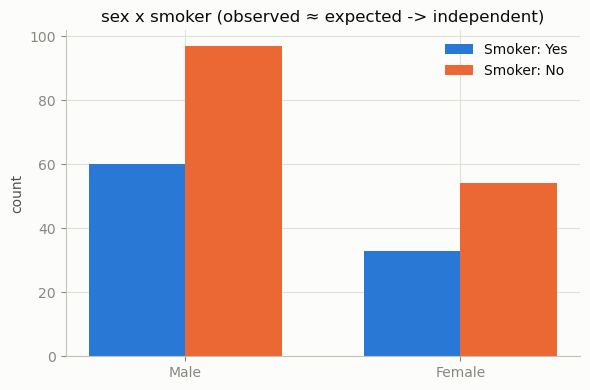

In [69]:
sexes = tbl_b.index.tolist()
smoker_cats = tbl_b.columns.tolist()
x = np.arange(len(sexes))
width = 0.35

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - width/2, tbl_b[smoker_cats[0]].values, width=width, color=BLUE, label=f"Smoker: {smoker_cats[0]}", zorder=2)
ax.bar(x + width/2, tbl_b[smoker_cats[1]].values, width=width, color=ORANGE, label=f"Smoker: {smoker_cats[1]}", zorder=2)
ax.set_xticks(x)
ax.set_xticklabels(sexes)
style_ax(ax)
ax.set_ylabel("count")
ax.set_title("sex x smoker (observed ≈ expected -> independent)")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

Expected frequencies are nearly identical to observed. **χ² = 0.000,
df = 1, p = 1.00** (with the standard Yates continuity correction applied to
this 2×2 table; uncorrected χ² = 0.0019, p = 0.965 — same conclusion either
way). p ≫ 0.05 → **fail to reject H0**. No association between sex and
smoking status in this sample.

### 5. Tip Prediction Regression 

Model: `tip ~ total_bill + size`

In [70]:
m5b = smf.ols("tip ~ total_bill + size", data=tips).fit()
print(m5b.summary())
X5b = sm.add_constant(tips[["total_bill", "size"]])
vif5b = pd.DataFrame({
    "variable": X5b.columns,
    "VIF": [variance_inflation_factor(X5b.values, i) for i in range(X5b.shape[1])]
})
print("\nVIF:\n", vif5b)
print(f"\nCorrelation(total_bill, size) = {tips['total_bill'].corr(tips['size']):.4f}")

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.468
Model:                            OLS   Adj. R-squared:                  0.463
Method:                 Least Squares   F-statistic:                     105.9
Date:                Thu, 30 Jul 2026   Prob (F-statistic):           9.67e-34
Time:                        21:35:07   Log-Likelihood:                -347.99
No. Observations:                 244   AIC:                             702.0
Df Residuals:                     241   BIC:                             712.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.6689      0.194      3.455      0.0

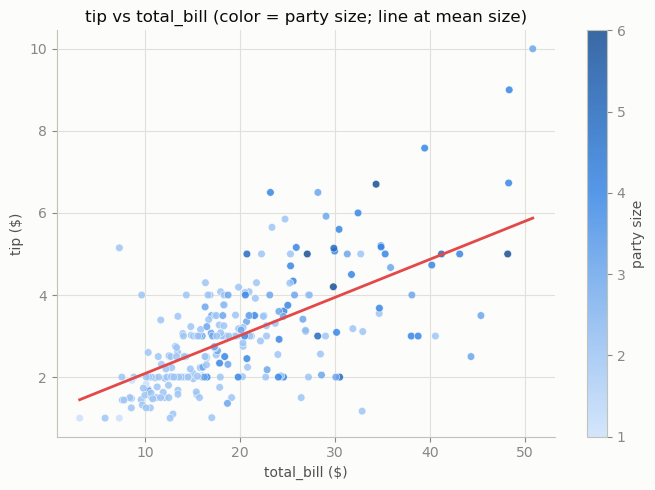

In [71]:
cmap = LinearSegmentedColormap.from_list("seq_blue", SEQ_BLUE)
b0b, b1b, b2b = m5b.params["Intercept"], m5b.params["total_bill"], m5b.params["size"]

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(tips["total_bill"], tips["tip"], c=tips["size"], cmap=cmap, s=30,
                 alpha=0.85, edgecolors="white", linewidth=0.4, zorder=2)
xs = np.linspace(tips["total_bill"].min(), tips["total_bill"].max(), 100)
ax.plot(xs, b0b + b1b * xs + b2b * tips["size"].mean(), color=RED, linewidth=2, zorder=3)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("party size")
style_ax(ax)
ax.set_xlabel("total_bill ($)")
ax.set_ylabel("tip ($)")
ax.set_title("tip vs total_bill (color = party size; line at mean size)")
plt.tight_layout()
plt.show()

R² = 0.468, Adj. R² = 0.463.

**(a) Interpretation:**
- **β1 (0.0927):** Holding party size constant, each **+$1** in total bill
  is associated with a **$0.093** increase in tip.
- **β2 (0.1926):** Holding total bill constant, each **additional guest** is
  associated with a **$0.193** increase in tip.

**(b) Partial t-tests:** `total_bill` is highly significant (t = 10.17,
p < 0.001); `size` is significant at α = 0.05 but more marginal (t = 2.26,
p = 0.025).

**(c) VIF & collinearity:** VIF(total_bill) = VIF(size) = 1.558.
`total_bill` and `size` are moderately correlated (r = 0.598 — bigger
parties tend to run up bigger bills), but VIF is well below the 5/10
concern threshold, so standard errors and the individual coefficient
estimates above remain trustworthy; collinearity risk is present but not
severe.

### 6. High-Tip Binary Logistic Model

Outcome: `high_tip = 1` if `tip ≥ $3.00`, else 0 (base rate 49.6%).

Model: `logit(high_tip) = β0 + β1(total_bill) + β2(smoker)`

**(a) Justification:** a linear probability model
for `high_tip` could predict probabilities outside [0, 1]; the logit link
keeps predictions valid probabilities and correctly models the
binary/Bernoulli outcome.

In [72]:
X6b = sm.add_constant(tips[["total_bill", "is_smoker"]])
y6b = tips["high_tip"]
m6b = sm.Logit(y6b, X6b).fit(disp=0)
print(m6b.summary())
orB = np.exp(m6b.params)
ciB = m6b.conf_int()
ciB_exp = np.exp(ciB)
print("\nOdds Ratios:\n", pd.DataFrame({"OR": orB, "CI_low": ciB_exp[0], "CI_high": ciB_exp[1]}))
print(f"\nhigh_tip base rate: {y6b.mean():.3f}")

                           Logit Regression Results                           
Dep. Variable:               high_tip   No. Observations:                  244
Model:                          Logit   Df Residuals:                      241
Method:                           MLE   Df Model:                            2
Date:                Thu, 30 Jul 2026   Pseudo R-squ.:                  0.2508
Time:                        21:35:07   Log-Likelihood:                -126.71
converged:                       True   LL-Null:                       -169.12
Covariance Type:            nonrobust   LLR p-value:                 3.815e-19
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.6747      0.534     -6.885      0.000      -4.721      -2.629
total_bill     0.1912      0.028      6.904      0.000       0.137       0.245
is_smoker      0.1424      0.320      0.445      0.6

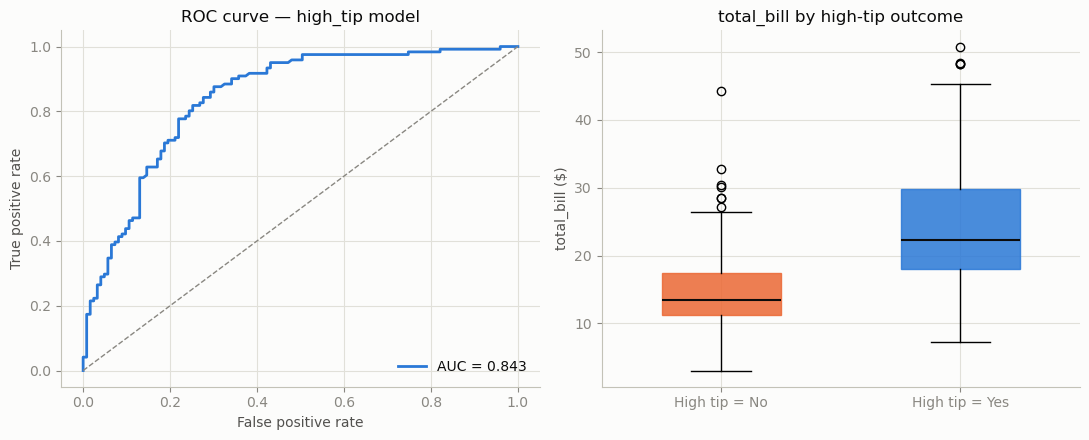

In [73]:
pred_prob_b = m6b.predict(X6b)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ax = axes[0]
fprb, tprb, _ = roc_curve(y6b, pred_prob_b)
ax.plot(fprb, tprb, color=BLUE, linewidth=2, label=f"AUC = {roc_auc_score(y6b, pred_prob_b):.3f}")
ax.plot([0, 1], [0, 1], color=INK_MUTED, linestyle="--", linewidth=1)
style_ax(ax)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curve — high_tip model")
ax.legend(frameon=False, loc="lower right")

ax = axes[1]
data = [tips.loc[tips.high_tip == 0, "total_bill"].values, tips.loc[tips.high_tip == 1, "total_bill"].values]
bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                 medianprops=dict(color=INK_PRIMARY, linewidth=1.5))
for patch, color in zip(bp["boxes"], [ORANGE, BLUE]):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
    patch.set_edgecolor(color)
ax.set_xticklabels(["High tip = No", "High tip = Yes"])
style_ax(ax)
ax.set_ylabel("total_bill ($)")
ax.set_title("total_bill by high-tip outcome")

plt.tight_layout()
plt.show()

**(c) Odds ratios & staff insight:**
- **total_bill: OR = 1.2107** [95% CI 1.147, 1.278] — each **+$1** in total
  bill is associated with a **21.1% increase** in the odds of a high tip
  (≥$3), holding smoker status constant. This is the dominant, statistically
  robust driver.
- **smoker: OR = 1.153** [95% CI 0.616, 2.158] — smoker tables show 15.3%
  higher odds of a high tip than non-smokers, but the effect is **not
  statistically significant** (p = 0.656, CI spans 1).

**Actionable staff insight :** Bill size is the reliable signal for
anticipating a high tip and larger checks warrant continued strong service
focus. Smoking status is **not** a dependable signal and should not factor
into service prioritization.